# 实验2 课件代码整理版

这个 notebook 按照课件 PDF 的顺序，把示例代码整理成了可直接运行的 `ipynb`。

说明：

- 代码主体尽量保持课件原意和原结构
- 课件中使用 `d:\actor_edges.csv`，这里改为当前目录下自动生成 `actor_edges.csv`
- 为避免中文乱码，统一设置了中文字体显示


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False


## 预处理：生成课件中用到的 `actor_edges.csv`

课件代码依赖一个真实网络边文件，这里在 notebook 所在目录生成一个可运行的示例文件。


In [ ]:
actor_edges_path = Path("actor_edges.csv")

actor_edges = pd.DataFrame(
    [
        ("演员A", "演员B", 5),
        ("演员A", "演员C", 3),
        ("演员A", "演员D", 4),
        ("演员B", "演员C", 6),
        ("演员B", "演员E", 2),
        ("演员C", "演员D", 5),
        ("演员C", "演员F", 4),
        ("演员D", "演员F", 3),
        ("演员D", "演员G", 2),
        ("演员E", "演员F", 4),
        ("演员E", "演员H", 1),
        ("演员F", "演员G", 5),
        ("演员F", "演员H", 2),
        ("演员G", "演员H", 3),
    ],
    columns=["from", "to", "weight"],
)
actor_edges.to_csv(actor_edges_path, index=False, encoding="utf-8-sig")
actor_edges.head()


## 实验2-1 节点的度、网络的平均度、度分布计算


### 1. 计算无向网络节点的度、网络的平均度、度分布


In [ ]:
# 创建一个无向无权网络，计算节点度、网络平均度、度分布
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4])
G.add_edges_from([(1, 2), (2, 3), (2, 4), (3, 4)])

# 获取网络G的度
d = nx.degree(G)
print("节点的度：", d)
d = dict(nx.degree(G))
print("节点的度：", d)
print("网络平均度为：", sum(d.values()) / len(G.nodes))

# 获取度分布
# 利用nx.degree_histogram(G)，返回所有位于区间[0, dmax]的度值的频率列表
x = list(range(max(d.values()) + 1))
y = [i / len(G.nodes) for i in nx.degree_histogram(G)]

# 画出度分布的图
plt.bar(x, y, width=0.1, color="blue")
plt.xlabel("$k$")
plt.ylabel("$P_{k}$")
plt.xlim([0, 4])
plt.show()


### 2. 创建无向加权网络，计算节点的加权度、边权、网络的平均度


In [ ]:
# 创建一个无向加权网络，计算节点的加权度、边权、网络的平均度
import networkx as nx
import matplotlib.pyplot as plt

WG = nx.Graph()
WG.add_nodes_from([1, 2, 3, 4, 5, 6])
WG.add_weighted_edges_from(
    [
        (1, 2, 3.0), (1, 3, 1.0), (2, 4, 4.0), (2, 5, 1.5),
        (3, 5, 2.0), (3, 6, 3.5), (4, 5, 2.5), (4, 6, 0.5)
    ]
)
w = [WG[e[0]][e[1]]["weight"] for e in WG.edges()]
nx.draw(WG, node_size=500, width=w, with_labels=True)
plt.show()

# 获取网络节点的加权度（即点权）
print("网络节点的加权度")
print(nx.degree(WG, weight="weight"), end="\n")

# 获取每条边的权重（即边权）
print("网络的边权")
for e in WG.edges():
    print(WG[e[0]][e[1]]["weight"], end=" ")

# 获取平均度
d = dict(nx.degree(WG, weight="weight"))
print("\n网络平均度为：", sum(d.values()) / len(WG.nodes))


### 3. 计算有向网络节点的入度、出度、网络的平均度


节点的入度 [(1, 0), (2, 10), (3, 6), (4, 4), (5, 1), (6, 5)]
节点的出度 [(1, 7), (2, 2), (3, 3), (4, 3), (5, 11), (6, 0)]
网络的平均入度为： 4.333333333333333
网络的平均出度为： 4.333333333333333


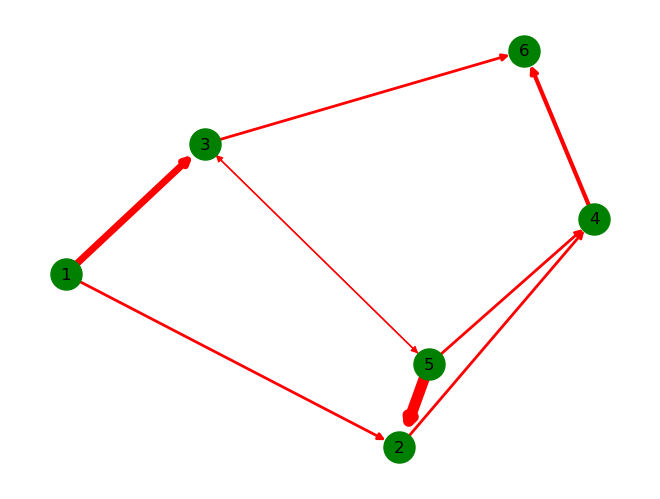

In [1]:
# 有向加权网络的节点入度和出度，网络的平均度
import networkx as nx
import matplotlib.pyplot as plt

DG = nx.DiGraph()
DG.add_nodes_from([1, 2, 3, 4, 5, 6])
DG.add_weighted_edges_from(
    [(1, 2, 2), (1, 3, 5), (2, 4, 2), (3, 5, 1), (4, 6, 3), (5, 2, 8), (5, 4, 2), (5, 3, 1), (3, 6, 2)]
)
w = [DG[e[0]][e[1]]["weight"] for e in DG.edges()]
print("节点的入度", DG.in_degree(DG, weight="weight"), end="\n")
print("节点的出度", DG.out_degree(DG, weight="weight"), end="\n")

# 获取平均入度
d1 = dict(DG.in_degree(DG, weight="weight"))
print("网络的平均入度为：", sum(d1.values()) / len(DG.nodes))

# 获取平均出度
d2 = dict(DG.out_degree(DG, weight="weight"))
print("网络的平均出度为：", sum(d2.values()) / len(DG.nodes))

nx.draw(DG, node_color="green", edge_color="red", width=w, node_size=500, with_labels=True)
plt.show()


### 4. 计算真实网络节点的度、网络的平均度、度分布


In [ ]:
# 真实网络度分布直方图
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv

plt.rc("font", family="SimHei")
df = pd.read_csv("actor_edges.csv")
G = nx.from_pandas_edgelist(df, "from", "to", "weight", create_using=nx.Graph())

# 获取网络节点的加权度
print("网络节点的加权度")
print(nx.degree(G, weight="weight"), end="\n")

# 获取平均度
d = dict(nx.degree(G, weight="weight"))
print("\n网络平均度为：", sum(d.values()) / len(G.nodes))


In [ ]:
# 定义函数get_pdf计算度分布
def get_pdf(G):
    all_k = [G.degree(i, weight="weight") for i in G.nodes()]
    k = list(set(all_k))
    N = len(G.nodes())

    Pk = []
    for ki in sorted(k):
        c = 0
        for i in G.nodes():
            if G.degree(i, weight="weight") == ki:
                c += 1
        Pk.append(c / N)

    return sorted(k), Pk


mid_d, p = get_pdf(G)

# 绘制网络G的度分布直方图
width = 0.5
plt.figure(figsize=(8, 6))
plt.bar(mid_d, p, width, color="b")
plt.title("度分布直方图", fontsize=18)
plt.xlabel("k", fontsize=18)
plt.ylabel("P(k)", fontsize=18)
plt.tick_params(labelsize=18)
plt.savefig("fig.png", dpi=600)
plt.show()


## 实验2-2 网络直径、最短路径、最短路径长度、网络密度、聚类系数等拓扑参数的计算


### 5. 计算网络的直径、最短路径、最短路径长度、平均路径长度、网络密度


In [ ]:
# 计算网络的直径、最短路径、最短路径长度、效率、平均路径长度、网络密度
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([(1, 2), (2, 3), (2, 5), (3, 4), (4, 5)])

print("网络的直径为：", nx.diameter(G))
print("节点1和4的最短路径", nx.shortest_path(G, source=1, target=4))
print("节点1和4的所有的最短路径", list(nx.all_shortest_paths(G, source=1, target=4)))
print("节点1和4的最短路径长度", nx.shortest_path_length(G, source=1, target=4))
print("网络的平均路径长度", nx.average_shortest_path_length(G))
print("网络的密度为：", nx.density(G))

nx.draw(G, node_size=500, with_labels=True)
plt.show()


### 6. 非连通图的最短路径长度计算


In [ ]:
# 非连通图的最短路径长度计算
import networkx as nx

# 创建一个非连通图
G = nx.Graph()
G.add_edges_from([(1, 2), (2, 3)])
G.add_node(4)

# 获取所有连通分量
connected_components = list(nx.connected_components(G))

# 计算每个连通分量的平均最短路径长度
for i, component in enumerate(connected_components):
    subgraph = G.subgraph(component)
    avg_shortest_path = nx.average_shortest_path_length(subgraph)
    print(f"第 {i + 1} 个连通分量的平均最短路径长度: {avg_shortest_path}")


### 7. 计算节点的聚类系数、网络的聚类系数、网络的横截性


In [ ]:
# 计算节点的聚类系数、网络的聚类系数、网络的横截性
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)])
plt.figure(figsize=(8, 3))

plt.subplot(131)
nx.draw(G, node_size=500, with_labels=True)
print("CC of node 1: ", nx.clustering(G, 1))

G.remove_edges_from([(2, 4), (3, 4), (3, 5)])
# 平均聚类系数
print("平均聚类系数", nx.average_clustering(G))
# 全局聚类系数
print("全局聚类系数", nx.transitivity(G))

plt.subplot(132)
nx.draw(G, node_size=500, with_labels=True)
print("CC of node 1: ", nx.clustering(G, 1))

G.remove_edges_from([(2, 3), (2, 5), (4, 5)])
plt.subplot(133)
nx.draw(G, node_size=500, with_labels=True)
print("CC of node 1: ", nx.clustering(G, 1))
plt.show()


### 8. 计算真实网络的直径、平均路径长度、网络密度、节点聚类系数、平均聚类系数、横截性


In [ ]:
# 真实网络的直径、平均路径长度、网络密度、节点的聚类系数、网络的聚类系数、网络的横截性
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import csv

df = pd.read_csv("actor_edges.csv")
G = nx.from_pandas_edgelist(df, "from", "to", "weight", create_using=nx.Graph())

print("网络的直径为：", nx.diameter(G))
print("网络的平均路径长度", nx.average_shortest_path_length(G))
print("网络的密度为：", nx.density(G))
print("节点的聚类系数：", nx.clustering(G))
print("网络的平均聚类系数", nx.average_clustering(G))
print("网络的全局聚类系数", nx.transitivity(G))


## 说明

上面是课件中的主要示例代码整理版。由于 PDF 是截图排版，个别地方我做了最小化规范处理：

- 统一补上了 `plt.show()`
- 把外部文件路径改成了当前目录下的 `actor_edges.csv`
- 保留了课件中的变量名和计算逻辑，便于对照实验报告
